# Machine Learning Modeling - Churn Prediction

In [30]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import time

# Set random seed 
np.random.seed(42)

In [31]:
sys.path.append(os.path.abspath('..'))

from src.models import (
    LogisticRegression, 
    KNearestNeighbors, 
    NaiveBayes, 
    RandomForest,
    ModelEvaluator
)
from src.data_processing import load_processed_data
from src.visualization import DataVisualizer

visualizer = DataVisualizer()

# Training Preparation

In [32]:
def load_data(version):
    X_train = load_processed_data(f'../data/processed/X_train_{version}.npy')
    X_test = load_processed_data(f'../data/processed/X_test_{version}.npy')
    y_train = load_processed_data(f'../data/processed/y_train_{version}.npy')
    y_test = load_processed_data(f'../data/processed/y_test_{version}.npy')
    return X_train, X_test, y_train, y_test

def train_model(model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    y_pred_test = model.predict(X_test)
    test_acc = ModelEvaluator.accuracy(y_test, y_pred_test)
    metrics = ModelEvaluator.precision_recall_f1(y_test, y_pred_test)
    
    return {
        'test_acc': test_acc,
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1_score'],
        'time': train_time
    }

def get_models():
    models = {
        'Logistic Regression': LogisticRegression(learning_rate=0.1, n_iterations=500, regularization=0.01),
        'KNN': KNearestNeighbors(k=5),
        'Naive Bayes': NaiveBayes(),
        'Random Forest': RandomForest(n_estimators=50, max_depth=10)
    }
    return models

# Train on Basic Dataset

In [33]:
X_train_b, X_test_b, y_train_b, y_test_b = load_data('basic')

Loaded processed data from ../data/processed/X_train_basic.npy
Loaded processed data from ../data/processed/X_test_basic.npy
Loaded processed data from ../data/processed/y_train_basic.npy
Loaded processed data from ../data/processed/y_test_basic.npy


In [34]:
results_basic = {}
for name, model in get_models().items():
    print(f'Training {name}...')
    results_basic[name] = train_model(model, X_train_b, y_train_b, X_test_b, y_test_b)
    print(f"  Acc: {results_basic[name]['test_acc']:.4f}, F1: {results_basic[name]['f1']:.4f}")

Training Logistic Regression...
  Acc: 0.8889, F1: 0.5731
Training KNN...
  Acc: 0.9012, F1: 0.6255
Training Naive Bayes...
  Acc: 0.8716, F1: 0.5975
Training Random Forest...
  Acc: 0.9457, F1: 0.8103


# Train on Enhanced Dataset

In [35]:
X_train_e, X_test_e, y_train_e, y_test_e = load_data('enhanced')

Loaded processed data from ../data/processed/X_train_enhanced.npy
Loaded processed data from ../data/processed/X_test_enhanced.npy
Loaded processed data from ../data/processed/y_train_enhanced.npy
Loaded processed data from ../data/processed/y_test_enhanced.npy


In [36]:
results_enhanced = {}
for name, model in get_models().items():
    print(f'Training {name}...')
    results_enhanced[name] = train_model(model, X_train_e, y_train_e, X_test_e, y_test_e)
    print(f"  Acc: {results_enhanced[name]['test_acc']:.4f}, F1: {results_enhanced[name]['f1']:.4f}")

Training Logistic Regression...
  Acc: 0.8574, F1: 0.8591
Training KNN...
  Acc: 0.9232, F1: 0.9290
Training Naive Bayes...
  Acc: 0.8294, F1: 0.8307
Training Random Forest...
  Acc: 0.9671, F1: 0.9676


# Results Comparison

In [37]:
print(f"{'Model':<20} {'Version':<10} {'Acc':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Time(s)':>9}")
print('-' * 85)
for name in results_basic.keys():
    r_b = results_basic[name]
    r_e = results_enhanced[name]
    print(f"{name:<20} {'Basic':<10} {r_b['test_acc']:>8.4f} {r_b['precision']:>10.4f} {r_b['recall']:>8.4f} {r_b['f1']:>8.4f} {r_b['time']:>9.4f}")
    print(f"{name:<20} {'Enhanced':<10} {r_e['test_acc']:>8.4f} {r_e['precision']:>10.4f} {r_e['recall']:>8.4f} {r_e['f1']:>8.4f} {r_e['time']:>9.4f}")
    print('-' * 85)

Model                Version         Acc  Precision   Recall       F1   Time(s)
-------------------------------------------------------------------------------------
Logistic Regression  Basic        0.8889     0.7550   0.4618   0.5731    0.1701
Logistic Regression  Enhanced     0.8574     0.8599   0.8584   0.8591    0.2107
-------------------------------------------------------------------------------------
KNN                  Basic        0.9012     0.8068   0.5107   0.6255    0.0000
KNN                  Enhanced     0.9232     0.8741   0.9913   0.9290    0.0000
-------------------------------------------------------------------------------------
Naive Bayes          Basic        0.8716     0.6050   0.5902   0.5975    0.0020
Naive Bayes          Enhanced     0.8294     0.8356   0.8259   0.8307    0.0020
-------------------------------------------------------------------------------------
Random Forest        Basic        0.9457     0.9289   0.7187   0.8103  108.3741
Random Forest   

# Visualization

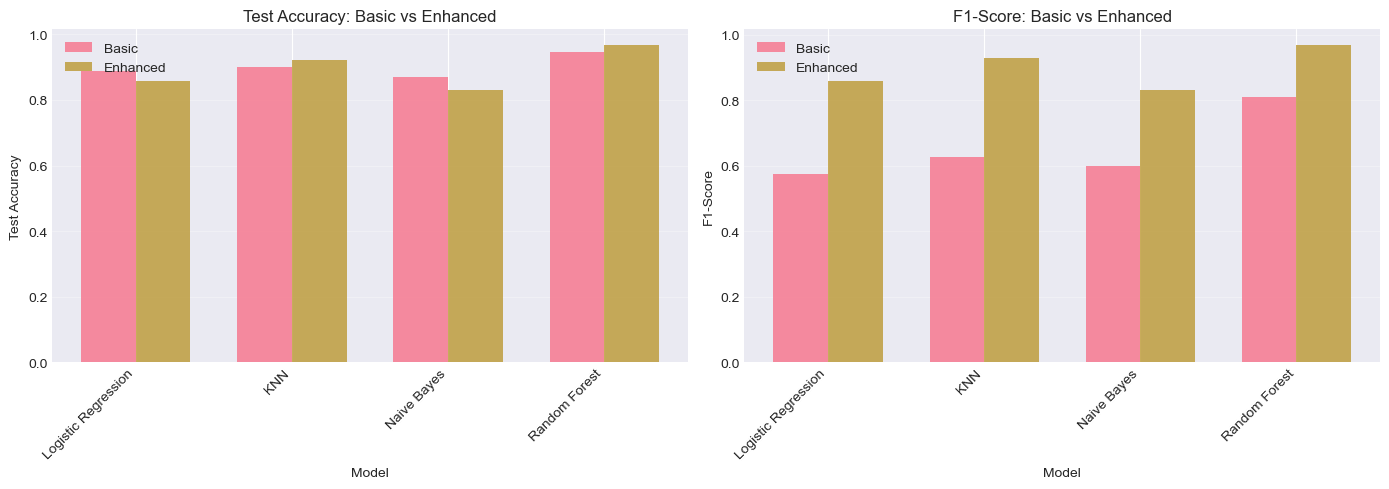

In [38]:
visualizer.plot_model_comparison(results_basic, results_enhanced)
plt.show()

# Cross Validation

In [39]:
from src.models import cross_validate

print("Performing 5-Fold Cross-Validation on Enhanced Dataset")
print(f"{'Model':<20} {'Mean Acc':>10} {'Std Dev':>10} {'Min Acc':>10} {'Max Acc':>10}")
print('-' * 70)

cv_models = get_models()
cv_results = {}

for name, model in cv_models.items():
    cv_result = cross_validate(model, X_train_e, y_train_e, k=5, metric='accuracy')
    cv_results[name] = cv_result
    print(f"{name:<20} {cv_result['mean']:>10.4f} {cv_result['std']:>10.4f} {cv_result['min']:>10.4f} {cv_result['max']:>10.4f}")

Performing 5-Fold Cross-Validation on Enhanced Dataset
Model                  Mean Acc    Std Dev    Min Acc    Max Acc
----------------------------------------------------------------------
Logistic Regression      0.8532     0.0041     0.8460     0.8581
KNN                      0.9143     0.0048     0.9088     0.9221
Naive Bayes              0.8138     0.0078     0.8026     0.8257
Random Forest            0.9651     0.0033     0.9614     0.9706


# Model Analysis & Insights

## Confusion Matrix Analysis - Enhanced Dataset

In [40]:
trained_models = {}
predictions = {}

for name, model in get_models().items():
    model.fit(X_train_e, y_train_e)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_e)


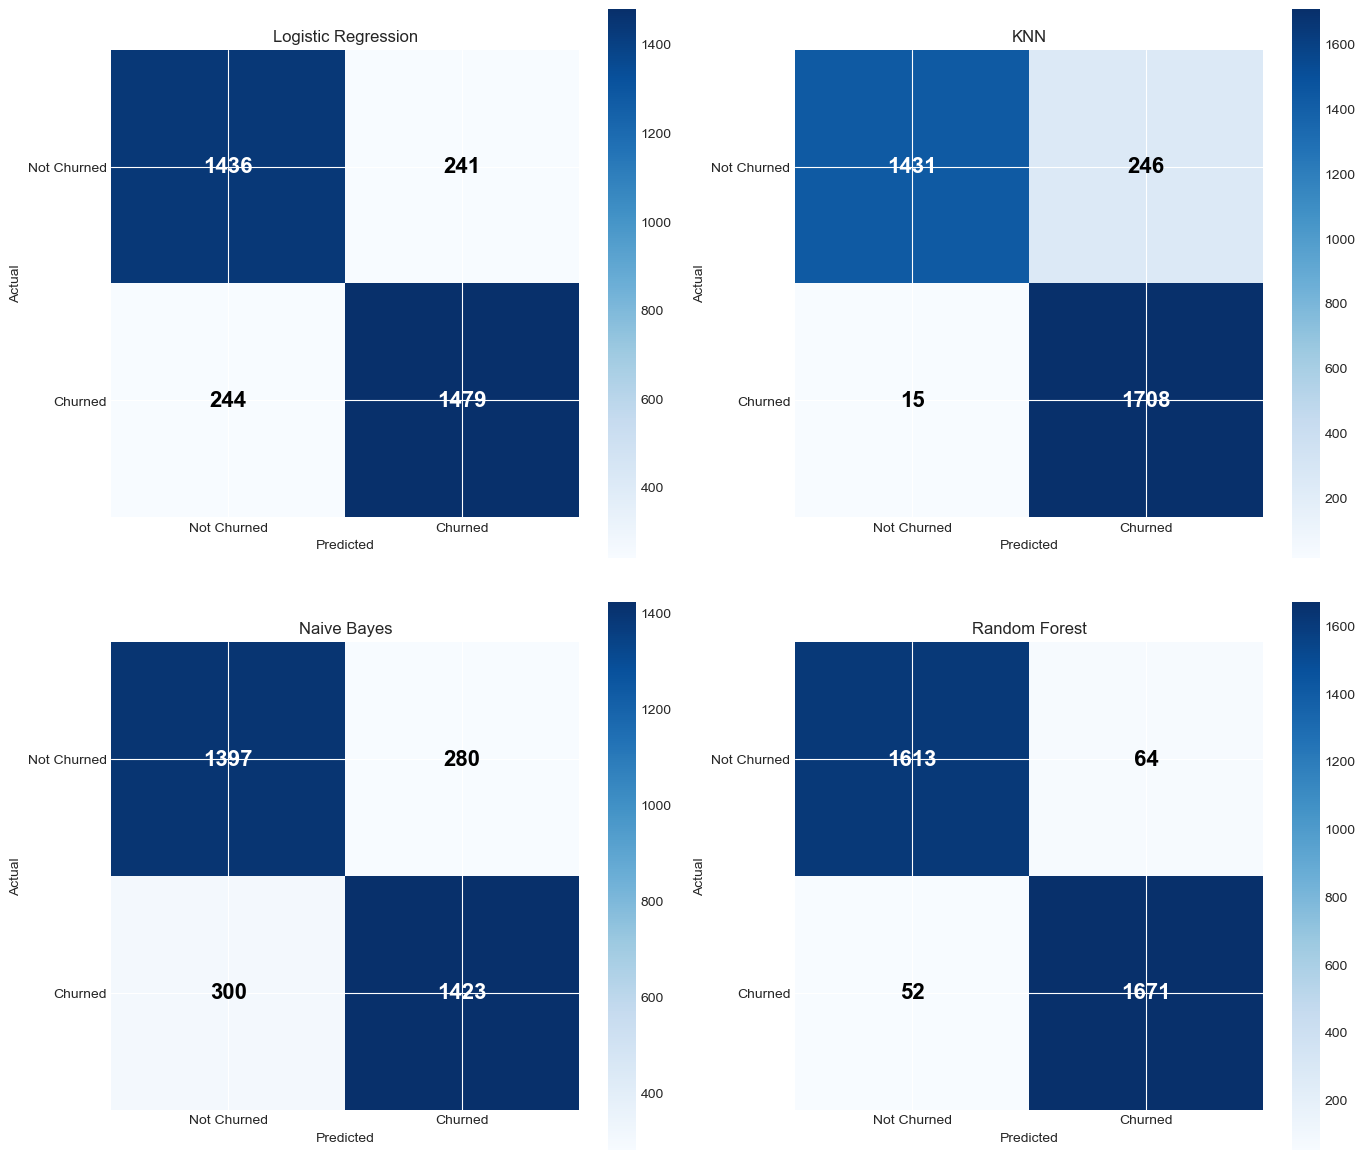

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

confusion_matrices = {}

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = ModelEvaluator.confusion_matrix(y_test_e, y_pred, n_classes=2)
    confusion_matrices[name] = cm
    
    ax = axes[idx]
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)
    
    ax.set(xticks=np.arange(2),
           yticks=np.arange(2),
           xticklabels=['Not Churned', 'Churned'],
           yticklabels=['Not Churned', 'Churned'],
           title=f'{name}',
           ylabel='Actual',
           xlabel='Predicted')
    
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, cm[i, j],
                          ha="center", va="center",
                          color="white" if cm[i, j] > cm.max() / 2 else "black",
                          fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## Detailed Confusion Matrix Metrics

In [42]:
print(f"{'Model':<20} {'TN':>8} {'FP':>8} {'FN':>8} {'TP':>8} {'Total':>8} {'Specificity':>12} {'Sensitivity':>12}")
print("─" * 110)

for name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    total = tn + fp + fn + tp
    
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"{name:<20} {tn:>8} {fp:>8} {fn:>8} {tp:>8} {total:>8} {specificity:>12.4f} {sensitivity:>12.4f}")


Model                      TN       FP       FN       TP    Total  Specificity  Sensitivity
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Logistic Regression      1436      241      244     1479     3400       0.8563       0.8584
KNN                      1431      246       15     1708     3400       0.8533       0.9913
Naive Bayes              1397      280      300     1423     3400       0.8330       0.8259
Random Forest            1613       64       52     1671     3400       0.9618       0.9698



- **TN (True Negatives)**: Dự đoán chính xác KHÔNG churn  
- **FP (False Positives)**: Dự đoán nhầm là churn  
- **FN (False Negatives)**: Dự đoán nhầm là không churn  
- **TP (True Positives)**: Dự đoán chính xác là churn  
- **Độ đặc hiệu (Specificity)**: TN / (TN + FP) – Khả năng nhận diện người không churn  
- **Độ nhạy (Sensitivity)**: TP / (TP + FN) – Khả năng nhận diện người churn

## Error Analysis

In [43]:
error_analysis = {}

for name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    
    total_errors = fp + fn
    total_predictions = tn + fp + fn + tp
    error_rate = total_errors / total_predictions
    
    type_1_error = fp / (tn + fp) if (tn + fp) > 0 else 0
    type_2_error = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    error_analysis[name] = {
        'total_errors': total_errors,
        'error_rate': error_rate,
        'type_1_error': type_1_error,
        'type_2_error': type_2_error,
        'fp': fp,
        'fn': fn
    }

print(f"{'Model':<20} {'Total Errors':>13} {'Error Rate':>12} {'Type I (FP)':>13} {'Type II (FN)':>14}")
for name, errors in error_analysis.items():
    print(f"{name:<20} {errors['total_errors']:>13} {errors['error_rate']:>11.2%} {errors['type_1_error']:>12.2%} {errors['type_2_error']:>13.2%}")


Model                 Total Errors   Error Rate   Type I (FP)   Type II (FN)
Logistic Regression            485      14.26%       14.37%        14.16%
KNN                            261       7.68%       14.67%         0.87%
Naive Bayes                    580      17.06%       16.70%        17.41%
Random Forest                  116       3.41%        3.82%         3.02%


# Conclusion 

### Mô hình tổng thể tốt nhất: Random Forest
- Giá trị kinh doanh: Độ chính xác cao trong việc dự đoán cả khách hàng rời bỏ và không rời bỏ  
- Ứng dụng: Phù hợp để triển khai thực tế nhờ hiệu suất cân bằng và ổn định  

---

### Mô hình bắt churner tốt nhất (Recall cao nhất - 99.13%): KNN 
- Giá trị kinh doanh: Giảm tối đa số churner bị bỏ sót, tăng cơ hội giữ chân  
- Ứng dụng: Dùng khi chi phí mất khách hàng rất cao hoặc mục tiêu là tối đa hóa giữ chân  

---

### Mô hình tránh cảnh báo sai tốt nhất (Specificity cao nhất - 96.18%): Random Forest
- Giá trị kinh doanh: Giảm lãng phí ngân sách giữ chân vào khách hàng trung thành  
- Ứng dụng: Thích hợp khi các chiến dịch chăm sóc hoặc ưu đãi tốn kém và cần tối ưu chi phí  

---

# Recommendation

- Ưu tiên triển khai mô hình Random Forest 
- Sử dụng mô hình KNN nếu mục tiêu ưu tiên là giữ chân khách hàng
- Đánh đổi khi chọn mô hình:
    - Recall cao: Bắt được nhiều churner hơn nhưng chi phí giữ chân tăng  
    - Specificity cao: Tiết kiệm chi phí nhưng có nguy cơ bỏ sót churner  
    - Cân bằng: Random Forest mang lại sự cân bằng tốt nhất giữa độ chính xác và chi phí  